<a href="https://colab.research.google.com/github/yuliia-naumeniuk/ecommerce-sales-performance-analysis/blob/main/E_Commerce_Sales_Performance_%26_Statistical_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Connecting to the database**


In [ ]:
# Installing a library to work with Google BigQuery
!pip install --upgrade google-cloud-bigquery

# Libraries
from google.colab import auth
from google.cloud import bigquery
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import kendalltau
from scipy.stats import mannwhitneyu
from scipy.stats import kruskal
from scipy.stats import f_oneway
import statsmodels.api as sm

# Authentication
auth.authenticate_user()

# Creating a BigQuery client
client = bigquery.Client(project="data-analytics-mate")

In [ ]:
# SQL query
query = """
SELECT
  s.date,
  s.ga_session_id,
  sp.continent,
  sp.country,
  sp.device,
  sp.browser,
  sp.mobile_model_name,
  sp.operating_system,
  sp.language,
  sp.name AS traffic_source,
  sp.channel AS traffic_channel,
  acs.account_id,
  acc.is_verified,
  acc.is_unsubscribed,
  p.category,
  p.name,
  p.price,
  p.short_description
FROM `DA.session` AS s
LEFT JOIN `DA.session_params` AS sp
  ON sp.ga_session_id = s.ga_session_id
LEFT JOIN `DA.account_session` AS acs
  ON acs.ga_session_id = s.ga_session_id
LEFT JOIN `DA.account` AS acc
  ON acc.id = acs.account_id
LEFT JOIN `DA.order` AS o
  ON o.ga_session_id = s.ga_session_id
LEFT JOIN `DA.product` AS p
  ON p.item_id = o.item_id
  """

In [ ]:
# Executing the query
query_job = client.query(query)  # Executing the SQL query
results = query_job.result()  # Waiting for the query to complete


# Converting results to a DataFrame
df = results.to_dataframe()


# Displaying the results
df.head()

,date,ga_session_id,continent,country,device,browser,mobile_model_name,operating_system,language,traffic_source,traffic_channel,account_id,is_verified,is_unsubscribed,category,name,price,short_description
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,(organic),Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(direct),Direct,<NA>,<NA>,<NA>,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(direct),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(direct),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


# **2. Exploratory data analysis**
# **2.1 Dataset overview**

1. ***date*** *- order date*
2. ***ga_session_id*** *- unique identifier for each session*
3. ***continent*** *- continent from which the order was placed*
4. ***country*** *- country from which the order was placed*
5. ***device*** *- device for the order*
6. ***browser*** *- browser for the order*
7. ***mobile_model_name*** *- device model name for the order*
8. ***operating_system*** *- operating system for the order*
9. ***language*** *- browser language for the order*
10. ***traffic_source*** *- marketing traffic source*
11. ***traffic_channel*** *- marketing traffic channel*
12. ***account_id*** *- unique identifier of a registered user*
13. ***is_verified*** *- user email verification status*
14. ***is_unsubscribed*** *- user newsletter subscription status*
15. ***category*** *- product category*
16. ***name*** *- product name*
17. ***price*** *- product price*
18. ***short_description*** *- short product description*

In [ ]:
# DataFrame structure and data type verification
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   date               349545 non-null  dbdate 
 1   ga_session_id      349545 non-null  Int64  
 2   continent          349545 non-null  object 
 3   country            349545 non-null  object 
 4   device             349545 non-null  object 
 5   browser            349545 non-null  object 
 6   mobile_model_name  349545 non-null  object 
 7   operating_system   349545 non-null  object 
 8   language           235279 non-null  object 
 9   traffic_source     349545 non-null  object 
 10  traffic_channel    349545 non-null  object 
 11  account_id         27945 non-null   Int64  
 12  is_verified        27945 non-null   Int64  
 13  is_unsubscribed    27945 non-null   Int64  
 14  category           33538 non-null   object 
 15  name               33538 non-null   object 
 16  pr

In [ ]:
# Number of rows
df.shape[0]
print(f"Number of rows: {df.shape[0]}")


# Number of columns
df.shape[1]
print(f"Number of columns: {df.shape[1]}")


# Numeric columns (number/which ones)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
len(numeric_cols)
print(f"Numeric columns: {len(numeric_cols)} - {numeric_cols}")


# Categorical columns (number/which ones)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
len(categorical_cols)
print(f"Categorical columns: {len(categorical_cols)} - {categorical_cols}")


# Datetime columns (number/which ones)
datetime_cols = df.select_dtypes(include=['datetime', 'datetime64', 'dbdate']).columns.tolist()
len(datetime_cols)
print(f"Datetime columns: {len(datetime_cols)} - {datetime_cols}")


# Number of unique sessions
unique_sessions = df['ga_session_id'].nunique()
print(f"Unique sessions: {unique_sessions}")


# Time period (min - max)
min_date = df['date'].min()
max_date = df['date'].max()
print (f"Time period: {min_date} - {max_date}")


# Duplicates
print(f"Duplicates: {df.duplicated().sum()}")


# Missing values
missing_values = df.isna().sum().sort_values(ascending=False).reset_index()
print(f"Missing values: \n{missing_values}")


# Top 3 columns with missing values
top_3_missing_values = missing_values.head(3)
print(f"Top 3 columns with missing values: \n{top_3_missing_values}")

Number of rows: 349545
Number of columns: 18
Numeric columns: 5 - ['ga_session_id', 'account_id', 'is_verified', 'is_unsubscribed', 'price']
Categorical columns: 12 - ['continent', 'country', 'device', 'browser', 'mobile_model_name', 'operating_system', 'language', 'traffic_source', 'traffic_channel', 'category', 'name', 'short_description']
Datetime columns: 1 - ['date']
Unique sessions: 349545
Time period: 2020-11-01 - 2021-01-31
Duplicates: 0
Missing values: 
                index       0
0     is_unsubscribed  321600
1         is_verified  321600
2          account_id  321600
3   short_description  316007
4                name  316007
5            category  316007
6               price  316007
7            language  114266
8       ga_session_id       0
9                date       0
10     traffic_source       0
11   operating_system       0
12  mobile_model_name       0
13            browser       0
14            country       0
15             device       0
16          continent  

In [ ]:
# Share of missing values in the columns
(df.isna().sum() / df.shape[0]).sort_values(ascending=False) * 100

,0
is_unsubscribed,92.005321
is_verified,92.005321
account_id,92.005321
short_description,90.405241
name,90.405241
category,90.405241
price,90.405241
language,32.689925
ga_session_id,0.000000
date,0.000000


*   Total number of rows: 349545

*   Total number of columns: 18

*   Number of numeric columns: 5 - *ga_session_id, account_id, is_verified, is_unsubscribed, price*

*   Number of categorical columns: 12 - *continent, country, device, browser, mobile_model_name, operating_system, language, traffic_source, traffic_channel, category, name, short_description*

*   Number of datetime columns: 1 - *date*

*   Number of unique sessions: 349545

*   Time period analyzed: 2020-11-01 - 2021-01-31

*   Number of duplicates: 0

*   Columns with missing (NaN) values: 8 - *is_unsubscribed, is_verified, account_id, short_description, name, category, price, language*

*   The columns with the highest proportion of missing (NaN) values: 3 - *is_unsubscribed, is_verified, account_id*











(EN)

Missing values in the ***is_unsubscribed***, ***is_verified***, and ***account_id*** columns are caused by users who are not logged in. If a user does not have an account, these attributes do not apply, so the values are empty.

Missing values in the ***language*** column appear because the language was not detected or provided for some sessions.

Missing values in the ***category***, ***name***, ***price***, and ***short_description*** columns appear because not all users made a purchase. For sessions without purchases, product information is not available, so these fields remain empty.

(PL)

Brakujące wartości w kolumnach ***is_unsubscribed***, ***is_verified***, ***account_id*** wynikają z obecności niezalogowanych użytkowników. Jeśli użytkownik nie posiada konta, te atrybuty nie mają zastosowania, dlatego wartości są puste.

W kolumnie ***language*** pojawiają się brakujące wartości, ponieważ język nie został wykryty lub przekazany dla części sesji.

Brakujące wartości w kolumnach ***category***, ***name***, ***price***, ***short_description*** pojawiają się dlatego, że nie wszyscy użytkownicy dokonali zakupów. Dla sesji bez zakupów informacje o produkcie są logicznie niedostępne, dlatego odpowiednie komórki pozostają puste.

# **2.2 Descriptive statistics**

In [ ]:
# Summary statistics of numerical data
df.describe()

,ga_session_id,account_id,is_verified,is_unsubscribed,price
count,349545.0,27945.0,27945.0,27945.0,33538.000000
mean,4992250296.631739,659005.065557,0.71698,0.16944,953.298679
std,2887450949.537772,13216.529465,0.450474,0.375147,1317.001775
min,1205.0,636133.0,0.0,0.0,3.000000
25%,2493646855.0,647576.0,0.0,0.0,170.000000
50%,4988476074.0,658952.0,1.0,0.0,445.000000
75%,7491286508.0,670414.0,1.0,0.0,1195.000000
max,9999997129.0,681962.0,1.0,1.0,9585.000000


In [ ]:
# Number of records per category
df["category"].value_counts()

,count
category,
Bookcases & shelving units,7630
Chairs,5952
Sofas & armchairs,4301
Tables & desks,2941
Beds,2926
Cabinets & cupboards,2318
Outdoor furniture,2229
Children's furniture,1702
Chests of drawers & drawer units,1452


In [ ]:
# Top 5 countries by number of records
df["country"].value_counts().nlargest(5)

,count
country,
United States,153470
India,32763
Canada,25994
United Kingdom,11003
France,6958


# **3. Analyzing and visualization**

Top 3 continents by total sales: 
continent
Americas    17665280.0
Asia         7601298.3
Europe       5934624.2
Name: price, dtype: float64


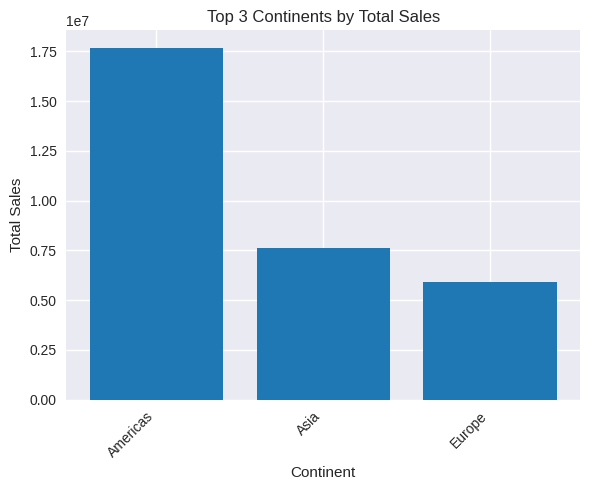

In [ ]:
# Top 3 continents by total sales
top_continents_total_sales = df.groupby("continent")["price"].sum().nlargest(3)
print(f"Top 3 continents by total sales: \n{top_continents_total_sales}")


# Visualization
plt.style.use("seaborn-v0_8")

plt.figure(figsize=(6, 5))
plt.bar(top_continents_total_sales.index, top_continents_total_sales.values, color="tab:blue")
plt.xlabel("Continent")
plt.ylabel("Total Sales")
plt.title("Top 3 Continents by Total Sales")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Top 3 continents by number of orders: 
continent
Americas    193179
Asia         83113
Europe       65135
Name: ga_session_id, dtype: Int64


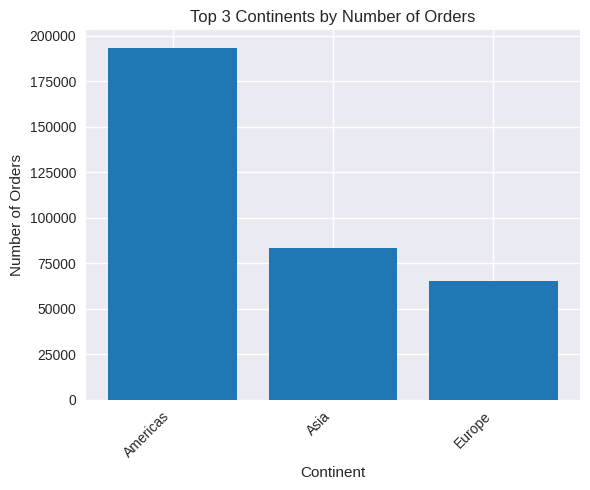

In [ ]:
# Top 3 continents by number of orders
top_continents_orders = df.groupby("continent")["ga_session_id"].count().nlargest(3)
print(f"Top 3 continents by number of orders: \n{top_continents_orders}")


# Visualization
plt.figure(figsize=(6, 5))
plt.bar(top_continents_orders.index, top_continents_orders.values, color="tab:blue")
plt.xlabel("Continent")
plt.ylabel("Number of Orders")
plt.title("Top 3 Continents by Number of Orders")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Top 5 countries by total sales: 
country
United States     13943553.9
India              2809762.0
Canada             2437921.0
United Kingdom      938317.9
France              710692.8
Name: price, dtype: float64


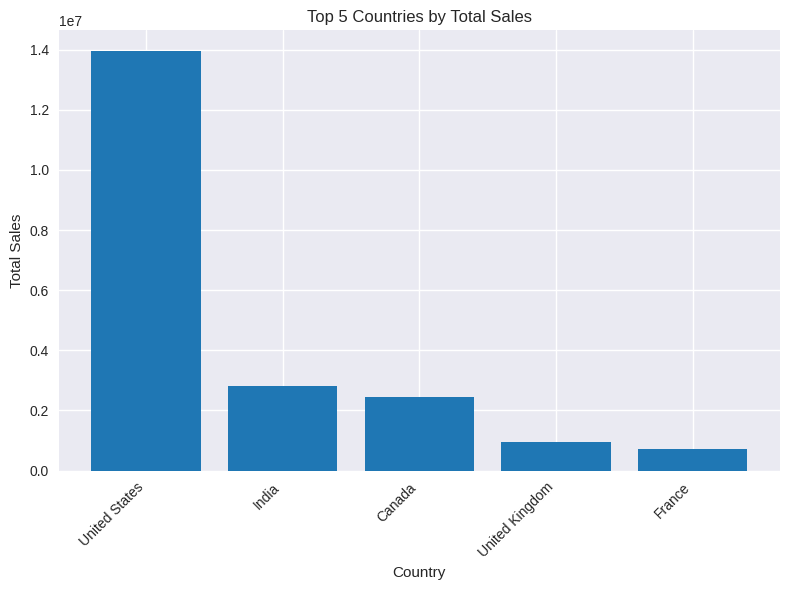

In [ ]:
# Top 5 countries by total sales
top_countries_total_sales = df.groupby("country")["price"].sum().nlargest(5)
print(f"Top 5 countries by total sales: \n{top_countries_total_sales}")


# Visualization
plt.figure(figsize=(8, 6))
plt.bar(top_countries_total_sales.index, top_countries_total_sales.values, color="tab:blue")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.title("Top 5 Countries by Total Sales")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Top 5 countries by number of orders: 
country
United States     153470
India              32763
Canada             25994
United Kingdom     11003
France              6958
Name: ga_session_id, dtype: Int64


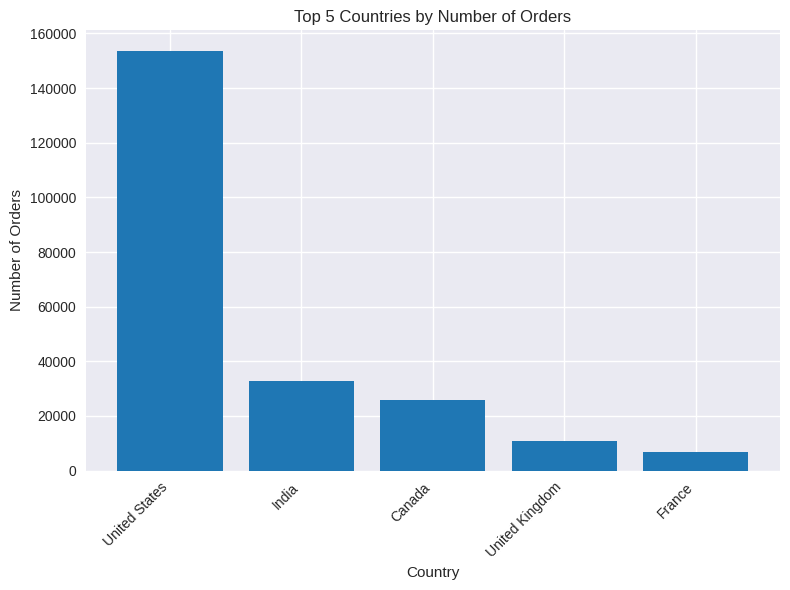

In [ ]:
# Top 5 countries by number of orders
top_countries_orders = df.groupby("country")["ga_session_id"].count().nlargest(5)
print(f"Top 5 countries by number of orders: \n{top_countries_orders}")


# Visualization
plt.figure(figsize=(8, 6))
plt.bar(top_countries_orders.index, top_countries_orders.values, color="tab:blue")
plt.xlabel("Country")
plt.ylabel("Number of Orders")
plt.title("Top 5 Countries by Number of Orders")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

(EN)

By analyzing total sales and the number of orders, we can identify the top 3 continents and the top 5 countries with the highest values:

**Top 3 continents:**

1. North and South America
2. Asia
3. Europe

**Top 5 countries:**

1. United States
2. India
3. Canada
4. United Kingdom
5. France

(PL)

Analizując łączną sprzedaż oraz liczbę zamówień, można wyróżnić Top 3 kontynenty oraz Top 5 krajów o najwyższych wartościach tych wskaźników:

**Top 3 kontynenty:**
1.   Ameryka Północna i Południowa
2.   Azja
3.   Europa

**Top 5 krajów:**
1.   Stany Zjednoczone
2.   Indie
3.   Kanada
4.   Wielka Brytania
5.   Francja

Top 10 product categories by total sales: 
category
Sofas & armchairs                   8388254.5
Chairs                              6147748.8
Beds                                4919725.0
Bookcases & shelving units          3640818.1
Cabinets & cupboards                2336499.5
Outdoor furniture                   2142222.2
Tables & desks                      1790307.5
Chests of drawers & drawer units     906562.5
Bar furniture                        735503.0
Children's furniture                 467697.0
Name: price, dtype: float64


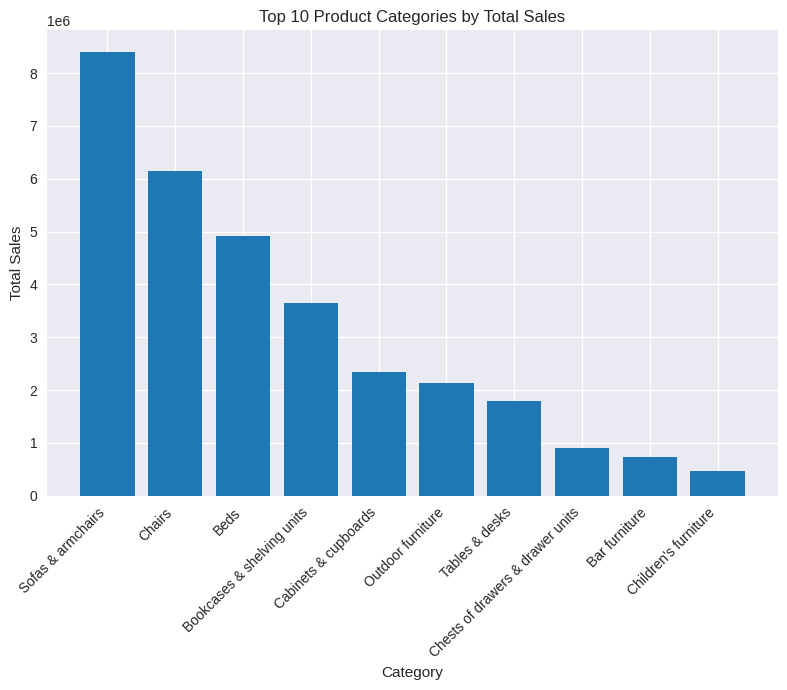

In [ ]:
# Top 10 product categories by total sales
top_categories_total_sales = df.groupby("category")["price"].sum().nlargest(10)
print(f"Top 10 product categories by total sales: \n{top_categories_total_sales}")


# Visualization
plt.figure(figsize=(8, 7))
plt.bar(top_categories_total_sales.index, top_categories_total_sales.values, color="tab:blue")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.title("Top 10 Product Categories by Total Sales")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Top 10 product categories by total sales in the United States: 
category
Sofas & armchairs                   3707144.5
Chairs                              2619773.8
Beds                                2213058.0
Bookcases & shelving units          1567606.9
Cabinets & cupboards                 994545.5
Outdoor furniture                    929245.2
Tables & desks                       777865.0
Chests of drawers & drawer units     382388.0
Bar furniture                        330805.0
Children's furniture                 207575.0
Name: price, dtype: float64


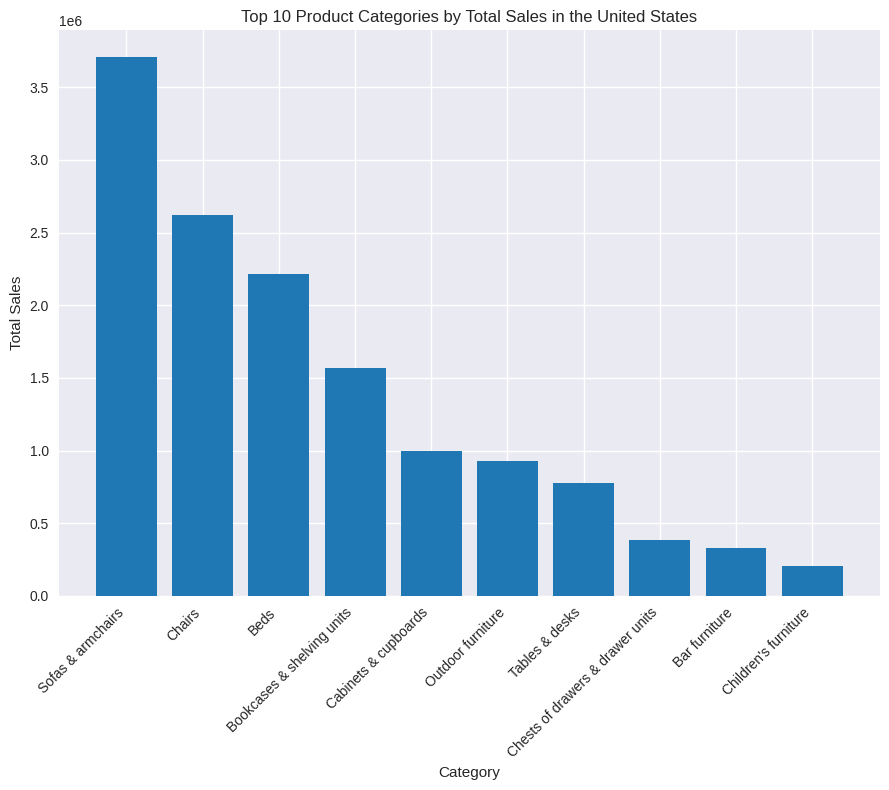

In [ ]:
# Top 10 product categories by total sales in the United States
df_us = df[df["country"] == "United States"]
top_categories_us = df_us.groupby("category")["price"].sum().nlargest(10)
print(f"Top 10 product categories by total sales in the United States: \n{top_categories_us}")


# Visualization
plt.figure(figsize=(9, 8))
plt.bar(top_categories_us.index, top_categories_us.values, color="tab:blue")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.title("Top 10 Product Categories by Total Sales in the United States")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

(EN)

We identified the top 10 product categories by sales in the United States. The results are very similar to the overall results, which means that the United States makes the largest contribution and has the biggest impact on the sales structure.

(PL)

Wyznaczyliśmy Top 10 kategorii produktów według sprzedaży w Stanach Zjednoczonych. Widzimy, że wyniki są bardzo podobne do ogólnych, co oznacza, że Stany Zjednoczone wnoszą największy wkład i mają największy wpływ na strukturę sprzedażową.

In [ ]:
# Total sales by device (% from total)
total_sales = df["price"].sum()
sales_by_device = df.groupby("device")["price"].sum().sort_values(ascending=False).reset_index()
sales_by_device["sales_pct"] = (sales_by_device["price"] / total_sales * 100).round(2)
sales_by_device

,device,price,sales_pct
0,desktop,18864039.0,59.00
1,mobile,12384225.8,38.73
2,tablet,723466.3,2.26


In [ ]:
# Total sales by device model name (% from total)
total_sales = df["price"].sum()
sales_by_model = df.groupby("mobile_model_name")["price"].sum().sort_values(ascending=False).reset_index()
sales_by_model["sales_pct"] = (sales_by_model["price"] / total_sales * 100).round(2)
sales_by_model

,mobile_model_name,price,sales_pct
0,Chrome,8899523.9,27.84
1,<Other>,6535330.8,20.44
2,Safari,6491062.1,20.30
3,iPhone,6420776.3,20.08
4,ChromeBook,1830458.7,5.73
5,Edge,697222.3,2.18
6,iPad,448854.2,1.40
7,Firefox,421066.9,1.32
8,Pixel 4 XL,118287.7,0.37
9,Pixel 3,109148.2,0.34


(EN)

By analyzing sales by device type, we can see that **desktop** devices have the largest share of total sales – 59%. The smallest share belongs to **tablets** – 2.26%.

Looking at device models, the top 3 models with the highest share of total sales are:

1. Chrome – 27.84%
2. Safari – 20.30%
3. iPhone – 20.08%

(PL)

Analizując sprzedaż według typów urządzeń, można stwierdzić, że największy udział w łącznej sprzedaży mają urządzenia typu **desktop** – 59%, natomiast najmniejszy udział przypada na **tablety** – 2,26%.

Jeśli chodzi o modele urządzeń, można wyróżnić 3 modele o największym udziale w całkowitej sprzedaży:
1.   Сhrome - 27,84%
2.   Safari - 20,30%
3.   iPhone - 20,08%

In [ ]:
# Total sales by traffic source
total_sales = df["price"].sum()
sales_by_source = df.groupby("traffic_source")["price"].sum().sort_values(ascending=False).reset_index()
sales_by_source["sales_pct"] = (sales_by_source["price"] / total_sales * 100).round(2)
sales_by_source

,traffic_source,price,sales_pct
0,(organic),10935239.9,34.20
1,(direct),7494923.4,23.44
2,<Other>,5897375.6,18.45
3,(referral),5641855.2,17.65
4,(data deleted),2002337.0,6.26


(EN)

By analyzing sales by traffic source, we can see that **organic** has the largest share of total sales – 34.20%. The smallest share belongs to **referral** – 17.65%.

(PL)

Analizując sprzedaż według źródeł ruchu, można stwierdzić, że największy udział w łącznej sprzedaży ma **organic** – 34,20%, natomiast najmniejszy udział przypada na **referral** – 17,65%.

In [ ]:
# Percentage of registered users with email verification

# Registered users
registered_users = df[df["account_id"].notna()]
total_registered = registered_users["account_id"].nunique()

# Verified users
verified_users = registered_users[registered_users["is_verified"]==1]
total_verified = verified_users["account_id"].nunique()

# Percentage
verification_pct = round(total_verified / total_registered * 100, 2)
print(f"Percentage of registered users with email verification: {verification_pct}%")

Percentage of registered users with email verification: 71.7%


(EN)

The percentage of registered users who confirmed their email address is 71.7%.

(PL)

Odsetek zarejestrowanych użytkowników, którzy potwierdzili adres e-mail, wynosi 71,7%.

In [ ]:
# Percentage of registered users who unsubscribed

# Unsubscribed users
unsubscribed_users = registered_users[registered_users["is_unsubscribed"]==1]
total_unsubscribed = unsubscribed_users["account_id"].nunique()

# Percentage
unsubscribed_pct = round(total_unsubscribed / total_registered * 100, 2)
print(f"Percentage of registered users who unsubsribed: {unsubscribed_pct}%")

Percentage of registered users who unsubsribed: 16.94%


(EN)

The percentage of registered users who unsubscribed from the newsletter is 16.94%.

(PL)

Odsetek zarejestrowanych użytkowników, którzy wypisali się z newslettera, wynosi 16,94%.

In [ ]:
# Sales contribution by subscription status

# Subscribed users
subscribed_users = registered_users[registered_users["is_unsubscribed"]==0]
total_subscribed = subscribed_users["account_id"].nunique()

# Subscribed/unsubscribed sales
subscribed_sales = subscribed_users["price"].sum()
unsubscribed_sales = unsubscribed_users["price"].sum()

# Percentage
subscribed_pct = round(subscribed_sales / total_sales * 100, 2)
unsubscribed_pct = round(unsubscribed_sales / total_sales * 100, 2)

print(f"Share of total sales generated by subscribed users: {subscribed_pct}%")
print(f"Share of total sales generated by unsubscribed users: {unsubscribed_pct}%")


Share of total sales generated by subscribed users: 6.73%
Share of total sales generated by unsubscribed users: 1.35%


(EN)

By analyzing the behavior of the two user groups in terms of sales, we can see that users subscribed to the newsletter generate much higher sales – 6.73%. Users who unsubscribed account for only 1.35% of sales.

(PL)

Analizując zachowanie dwóch grup użytkowników pod względem sprzedaży, można stwierdzić, że zdecydowanie wyższą sprzedaż generują użytkownicy zapisani na newsletter – 6,73%, natomiast użytkownicy, którzy się wypisali, odpowiadają jedynie za 1,35% sprzedaży.

In [ ]:
# Percentage of buyers among subscribed / unsubscribed users
# Subscribed buyers
subscribed_buyers = subscribed_users[subscribed_users["price"].notna()]
total_subscribed_buyers = subscribed_buyers["account_id"].nunique()

# Unsubscribed buyers
unsubscribed_buyers = unsubscribed_users[unsubscribed_users["price"].notna()]
total_unsubscribed_buyers = unsubscribed_buyers["account_id"].nunique()

# Percentage
subscribed_buyers_pct = round(total_subscribed_buyers / total_subscribed *100, 2)
unsubscribed_buyers_pct = round(total_unsubscribed_buyers / total_unsubscribed *100, 2)

print(f"Percentage of buyers among subscribed users: {subscribed_buyers_pct}%")
print(f"Percentage of buyers among unsubscribed users: {unsubscribed_buyers_pct}%")

Percentage of buyers among subscribed users: 10.06%
Percentage of buyers among unsubscribed users: 9.44%


(EN)

Among users subscribed to the newsletter, the percentage of buyers is 10.06%. Among users who unsubscribed, it is 9.44%. The difference between the groups is small, which shows that their purchasing behavior is similar.

(PL)

Wśród użytkowników zapisanych na newsletter odsetek kupujących wynosi 10,06%, podczas gdy wśród użytkowników, którzy się wypisali, jest to 9,44%. Różnica między grupami jest niewielka, co wskazuje na podobne zachowania zakupowe użytkowników.

In [ ]:
# Top countries by percent of registered users
registered_by_country = registered_users.groupby("country")["account_id"].nunique().nlargest(10)
percent_registered = (registered_by_country / total_registered * 100).round(2)
percent_registered

,account_id
country,
United States,44.32
India,9.62
Canada,7.40
United Kingdom,3.07
France,1.98
Spain,1.92
Taiwan,1.79
China,1.75
Germany,1.75


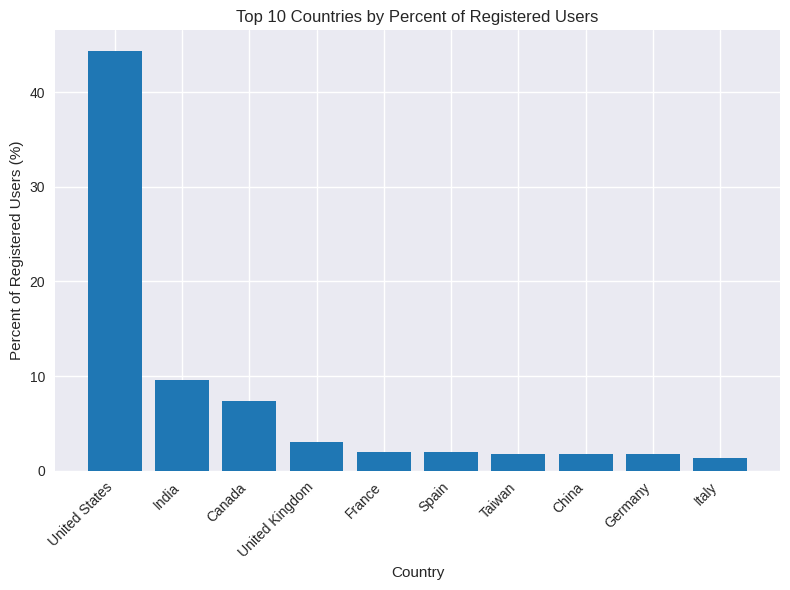

In [ ]:
# Visualization
plt.figure(figsize=(8, 6))
plt.bar(percent_registered.index, percent_registered.values, color="tab:blue")
plt.xlabel("Country")
plt.ylabel("Percent of Registered Users (%)")
plt.title("Top 10 Countries by Percent of Registered Users")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

(EN)

The clear leader in terms of share among registered users is the **United States** – 44.32%, which is almost half of all registered users. **India** (9.62%) and **Canada** (7.40%) follow, but their share is much lower compared to the leader.

(PL)

Zdecydowanym liderem pod względem udziału wśród zarejestrowanych użytkowników są **Stany Zjednoczone** — 44,32%, co stanowi niemal połowę wszystkich zarejestrowanych użytkowników.
Kolejne miejsca zajmują **Indie** (9,62%) oraz **Kanada** (7,40%), jednak ich udział jest znacząco niższy w porównaniu z liderem.

# **4. Sales dynamics**

          date     price
0   2020-11-01  244292.5
1   2020-11-02  355506.8
2   2020-11-03  498979.6
3   2020-11-04  339187.1
4   2020-11-05  391276.6
..         ...       ...
83  2021-01-23  290605.5
84  2021-01-24  243818.4
85  2021-01-25  305089.3
86  2021-01-26  372057.3
87  2021-01-27  286340.7

[88 rows x 2 columns]


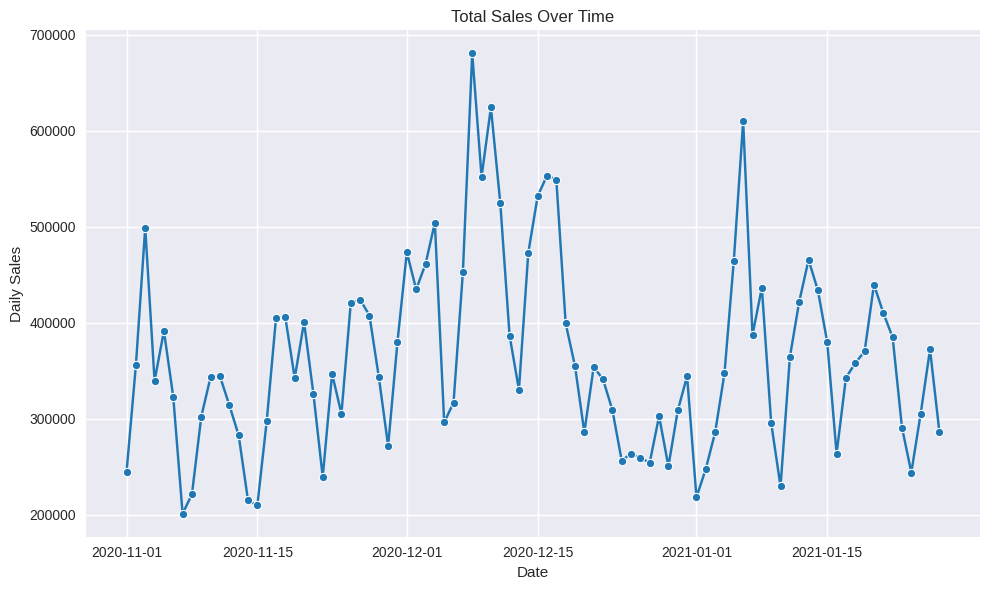

In [ ]:
# Total sales dynamics
sales_by_date = df.groupby("date")["price"].sum().reset_index().sort_values(by="date")
sales_by_date = sales_by_date[sales_by_date["price"] > 0]
print (sales_by_date)

# Visualization
plt.figure(figsize=(10,6))
sns.lineplot(data=sales_by_date, x="date", y="price", color="tab:blue", marker="o", ms=6)
plt.title("Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.tight_layout()
plt.show()

(EN)

There is no clear seasonality in sales. There are large daily fluctuations and single peaks, probably related to the holiday period. A longer observation period is needed to properly assess seasonality.

(PL)

Brak wyraźnej sezonowości sprzedaży. Występują duże dzienne wahania oraz pojedyncze piki, prawdopodobnie związane z okresem świątecznym. Do rzetelnej oceny sezonowości potrzebny jest dłuższy okres obserwacji.

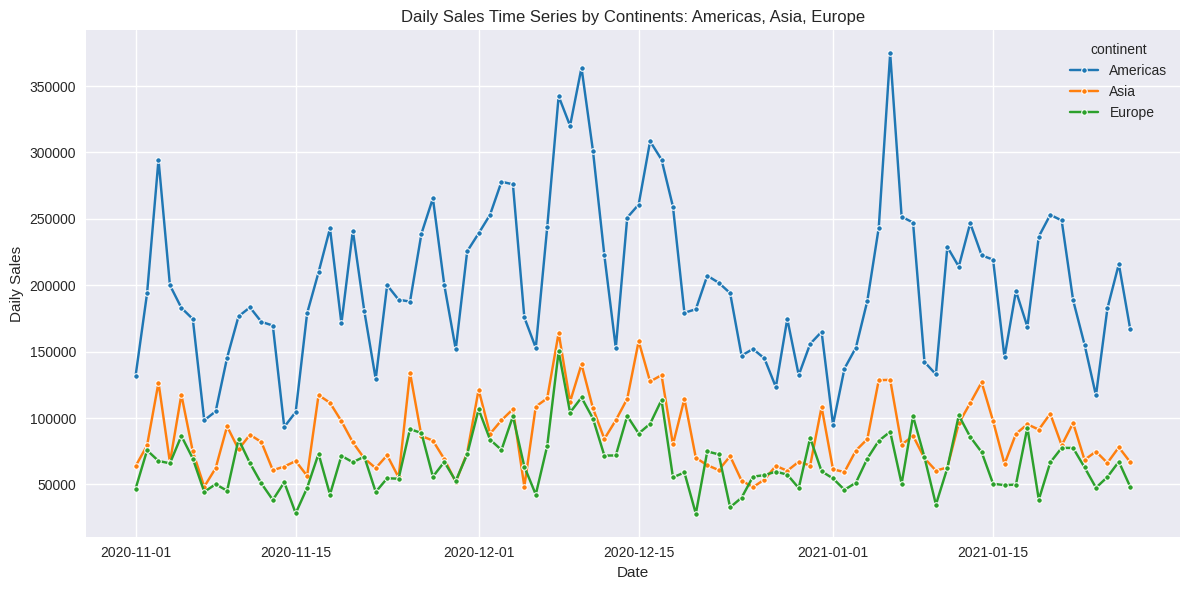

In [ ]:
# Total sales dynamics by continents: Americas, Asia, Europe
time_series_data = (df.groupby(["continent", "date"])["price"].sum().reset_index().sort_values(["date", "continent"]))
time_series_data = time_series_data[time_series_data["price"] > 0]

continents = ["Americas", "Asia", "Europe"]
time_series_data = time_series_data[time_series_data["continent"].isin(continents)]

# Visualization
plt.figure(figsize=(12,6))
sns.lineplot(data=time_series_data, x="date", y="price", hue="continent", palette="tab10", marker="o", ms=4) # tab10/colorblind - color-blind accessible
plt.title("Daily Sales Time Series by Continents: Americas, Asia, Europe")
plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.tight_layout()
plt.show()

(EN)

Daily sales on all three continents show large fluctuations. There is no clear seasonality, and increases and decreases in sales occur at similar times in all regions. America remains the leader, with the highest sales values.

(PL)

Sprzedaż dzienna na wszystkich trzech kontynentach wykazuje duże wahania. Nie obserwuje się wyraźnej sezonowości, a wzrosty i spadki sprzedaży występują w podobnych momentach we wszystkich regionach. Liderem pozostaje Ameryka, która osiąga najwyższe wartości sprzedaży.

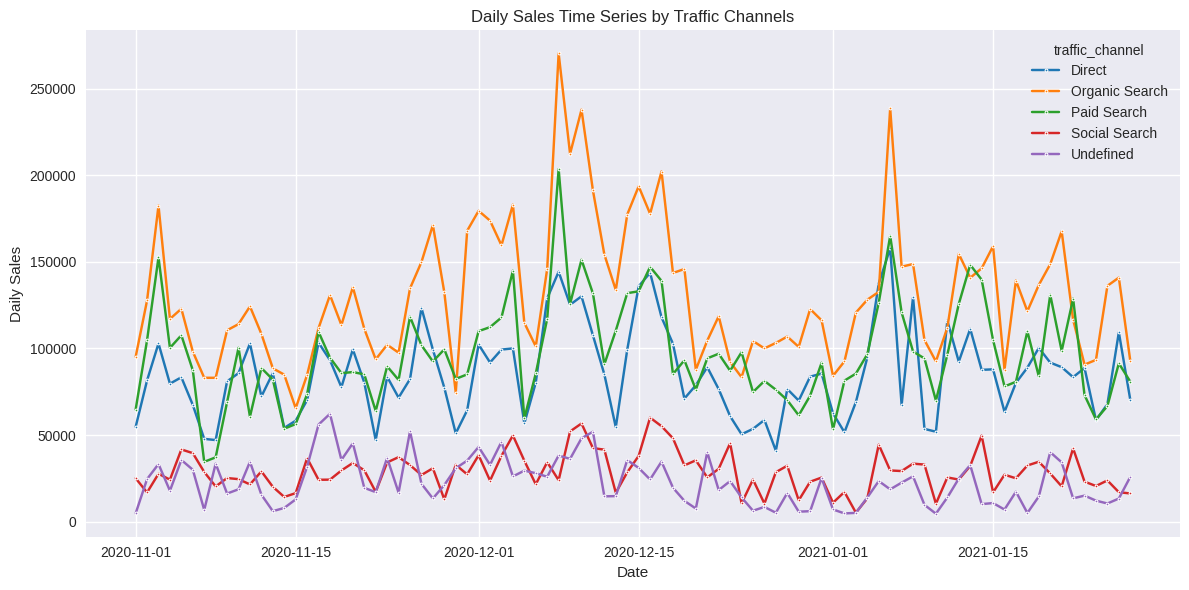

In [ ]:
# Total sales dynamics by traffic channel
time_series_data = (df.groupby(["traffic_channel", "date"])["price"].sum().reset_index().sort_values(["date", "traffic_channel"]))
time_series_data = time_series_data[time_series_data["price"] > 0]

# Visualization
plt.figure(figsize=(12,6))
sns.lineplot(data=time_series_data, x="date", y="price", hue="traffic_channel", palette="tab10", marker="o", ms=2)
plt.title("Daily Sales Time Series by Traffic Channels")
plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.tight_layout()
plt.show()

(EN)

Sales by traffic channel show high variability and no clear seasonality. The highest sales come from **Organic Search**. **Paid Search** and **Direct** also have an important share in total sales. The weakest results are from **Social Search** and **Undefined** channels.

(PL)

Sprzedaż według kanałów ruchu charakteryzuje się dużą zmiennością i brakiem sezonowości. Najwyższe wartości sprzedaży generuje kanał **Organic Search**, natomiast istotny udział w sprzedaży mają także kanały **Paid Search** oraz **Direct**. Najsłabsze wyniki osiągają kanały **Social Search** oraz **Undefined**.

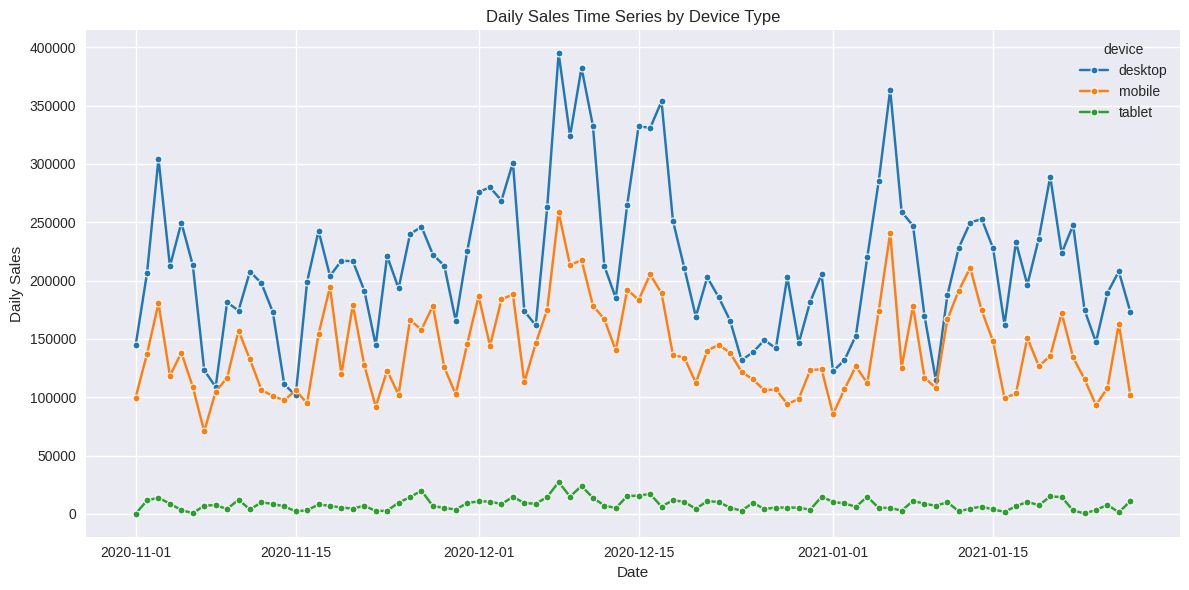

In [ ]:
# Total sales dynamics by device type
time_series_data = (df.groupby(["device", "date"])["price"].sum().reset_index().sort_values(["date", "device"]))
time_series_data = time_series_data[time_series_data["price"] > 0]

# Visualization
plt.figure(figsize=(12,6))
sns.lineplot(data=time_series_data, x="date", y="price", hue="device", palette="tab10", marker="o", ms=5)
plt.title("Daily Sales Time Series by Device Type")
plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.tight_layout()
plt.show()

(EN)

**Desktop** devices generate the highest sales, followed by **mobile** devices. For both groups, there are large daily changes and some single sales peaks, but no clear seasonality. Sales from **tablets** are the lowest and remain relatively stable.

(PL)

Najwyższe wartości sprzedaży generują urządzenia typu **desktop**, a następnie urządzenia **mobilne**. Dla obu tych grup widoczne są znaczne dzienne wahania oraz pojedyncze piki sprzedażowe, jednak bez wyraźnej sezonowości. Sprzedaż realizowana za pośrednictwem **tabletów** pozostaje na najniższym i stosunkowo stabilnym poziomie.

# **5. Pivot tables**

In [ ]:
# Sessions by traffic channel and device
filtered_df = df.dropna(subset=["ga_session_id", "traffic_channel", "device"])

pivot_table = pd.pivot_table(filtered_df, values="ga_session_id", index="traffic_channel", columns="device", aggfunc="nunique")
pivot_table = pivot_table.sort_values("desktop", ascending=False)
pivot_table = pivot_table.fillna(0)
pivot_table

device,desktop,mobile,tablet
traffic_channel,,,
Organic Search,72622,49014,2789
Paid Search,55167,37034,2140
Direct,47825,31745,1812
Social Search,16288,10988,638
Undefined,12527,8486,470


In [ ]:
# Total sales: Top 10 categories & Top 5 countries
filtered_df = df.dropna(subset=["price", "category", "country"])

top_10_categories = filtered_df.groupby("category")["price"].sum().nlargest(10).index.tolist()
top_5_countries = filtered_df.groupby("country")["price"].sum().nlargest(5).index.tolist()

top_df = filtered_df[(filtered_df["category"].isin(top_10_categories)) & (filtered_df["country"].isin(top_5_countries))]

pivot_table = pd.pivot_table(top_df, values="price", index="category", columns="country", aggfunc="sum")
pivot_table = pivot_table.fillna(0)
pivot_table

country,Canada,France,India,United Kingdom,United States
category,,,,,
Bar furniture,51724.0,11199.0,57657.0,22103.0,330805.0
Beds,354772.0,116414.0,358319.5,133816.0,2213058.0
Bookcases & shelving units,278981.9,73830.0,364507.4,113987.6,1567606.9
Cabinets & cupboards,181802.0,59101.5,191888.0,71684.5,994545.5
Chairs,417740.8,134029.4,544309.2,188519.4,2619773.8
Chests of drawers & drawer units,71952.0,21544.5,73111.0,36784.0,382388.0
Children's furniture,30264.0,14258.0,39177.0,13348.0,207575.0
Outdoor furniture,185322.8,40486.4,162289.4,57002.4,929245.2
Sofas & armchairs,692427.5,187735.0,788430.0,234812.0,3707144.5


In [ ]:
# Sessions by browser and device
filtered_df = df.dropna(subset=["ga_session_id", "browser", "device"])

pivot_table = pd.pivot_table(filtered_df, values="ga_session_id", index="browser", columns="device", aggfunc="count")
pivot_table = pivot_table.sort_values("desktop", ascending=False)
pivot_table = pivot_table.fillna(0)
pivot_table

device,desktop,mobile,tablet
browser,,,
Chrome,171859,62706,3895
Safari,16178,63957,3119
Edge,8016,7,0
Firefox,6063,370,0
<Other>,2313,6000,617
Android Webview,0,4227,218


In [ ]:
# Total sales by operating system in the top-5 countries
filtered_df = df.dropna(subset=["price", "operating_system", "country"])

top_5_countries = filtered_df.groupby("country")["price"].sum().nlargest(5).index.tolist()

top_df = filtered_df[filtered_df["country"].isin(top_5_countries)]

pivot_table = pd.pivot_table(top_df, values="price", index="operating_system", columns="country", aggfunc="sum")
pivot_table = pivot_table.sort_values("United States", ascending=False)
pivot_table = pivot_table.fillna(0)
pivot_table

country,Canada,France,India,United Kingdom,United States
operating_system,,,,,
Web,1420504.9,423314.5,1636264.1,574091.9,8029433.9
Windows,291967.2,115547.8,302176.8,128671.0,1677512.4
iOS,273461.5,69425.0,306010.8,109950.6,1601869.2
Android,219369.4,41341.5,259847.0,58712.4,1219799.9
Macintosh,170982.5,41043.0,249965.3,44272.0,1039808.1
<Other>,61635.5,20021.0,55498.0,22620.0,375130.4


# **6. Statistical analysis of relationships**

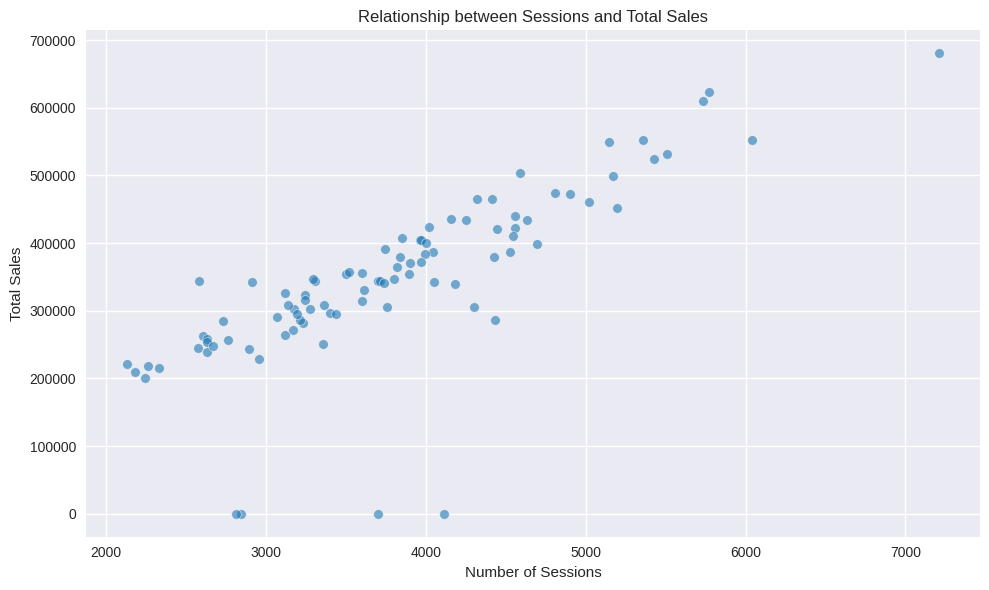

In [ ]:
# Relationship between sessions and total sales
sessions_by_date = df.groupby("date")["ga_session_id"].nunique().reset_index(name="sessions").sort_values("date")
sales_by_date = df.groupby("date")["price"].sum().reset_index(name="sales").sort_values("date")

daily_metrics = sessions_by_date.merge(sales_by_date, on="date")

# Visualization
plt.figure(figsize=(10,6))
sns.scatterplot(data=daily_metrics, x="sessions", y="sales", color="tab:blue", alpha=0.6)
plt.title("Relationship between Sessions and Total Sales")
plt.xlabel("Number of Sessions")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

In [ ]:
# Calculate Pearson correlation coefficient and p-value
r, p_value = pearsonr(daily_metrics["sessions"], daily_metrics["sales"])

print(f"r: {r:.3f}")
print(f"p-value: {p_value:.2e}")

r: 0.791
p-value: 6.48e-21


(EN)

The number of sessions and total sales show a **strong positive correlation** (Pearson correlation coefficient **r ≈ 0.79**).

The correlation is **statistically significant** (**p-value < 0.05**), which means there is a relationship between these metrics.


(PL)

Liczba sesji i całkowita sprzedaż wykazują **silną dodatnią korelację** (współczynnik korelacji Pearsona **r ≈ 0,79**).

Korelacja jest **statystycznie istotna** (**p-value < 0,05**), co wskazuje na istnienie zależności między tymi metrykami.

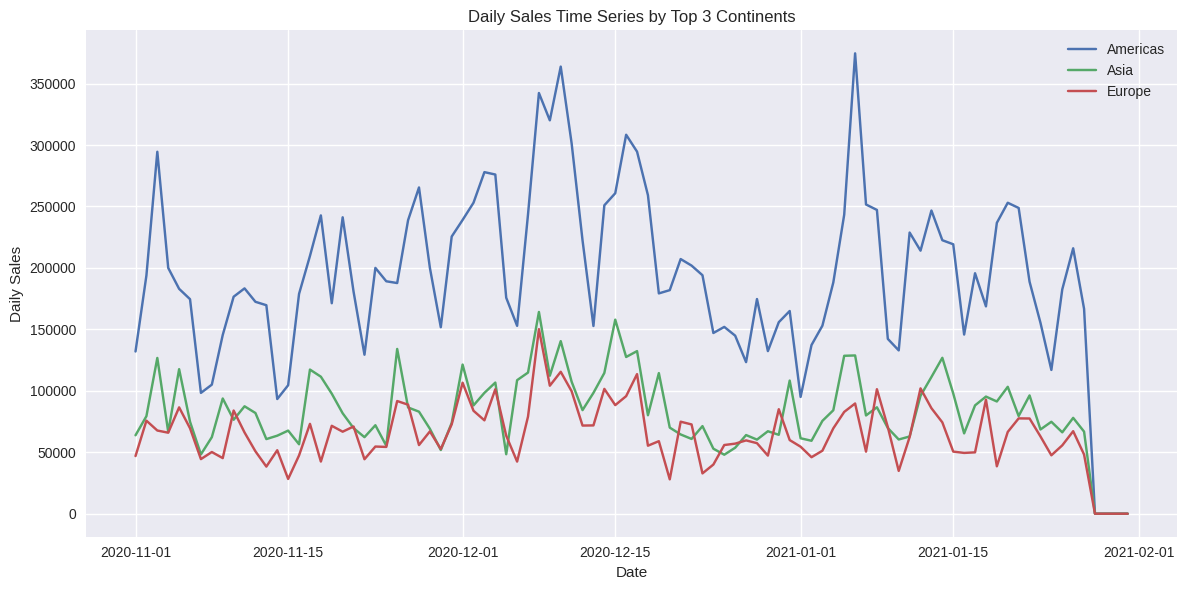

In [ ]:
# Relationship between total sales by Top 3 continents
# Top 3 continents by total sales
top_3_continents = df.groupby("continent")["price"].sum().sort_values(ascending=False).head(3).index

pivot_continent= df[df["continent"].isin(top_3_continents)].groupby(["date", "continent"])["price"].sum().unstack().dropna()

# Visualization
plt.figure(figsize=(12,6))

for column in pivot_continent.columns:
  plt.plot(pivot_continent.index, pivot_continent[column], label=column)

plt.title("Daily Sales Time Series by Top 3 Continents")
plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.legend()
plt.tight_layout()
plt.show()

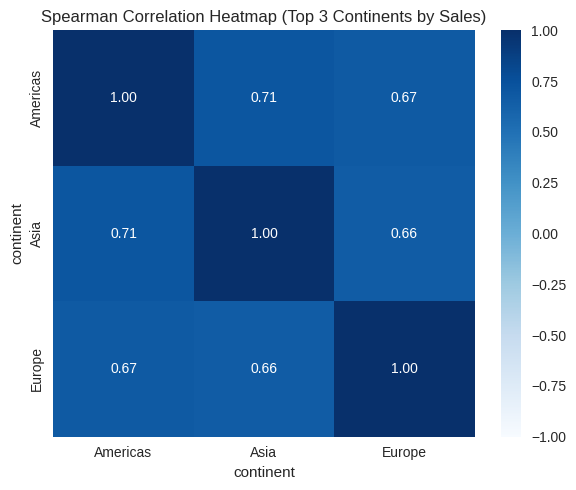

In [ ]:
# Calculate Spearman correlation
spearman_corr = pivot_continent.corr(method="spearman")

# Visualization
plt.figure(figsize=(6,5))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="Blues", vmin=-1, vmax=1)
plt.title("Spearman Correlation Heatmap (Top 3 Continents by Sales)")
plt.tight_layout()
plt.show()

In [ ]:
# Calculate Spearman correlation coefficient and p-value

# Americas vs Asia
rho, p = spearmanr(pivot_continent["Americas"], pivot_continent["Asia"])
print(f"Americas vs Asia: rho={rho:.3f}, p={p:.2e}")

# Americas vs Europe
rho, p = spearmanr(pivot_continent["Americas"], pivot_continent["Europe"])
print(f"Americas vs Europe: rho={rho:.3f}, p={p:.2e}")

# Asia vs Europe
rho, p = spearmanr(pivot_continent["Asia"], pivot_continent["Europe"])
print(f"Asia vs Europe: rho={rho:.3f}, p={p:.2e}")


Americas vs Asia: rho=0.710, p=2.32e-15
Americas vs Europe: rho=0.673, p=2.10e-13
Asia vs Europe: rho=0.657, p=1.13e-12


(EN)

Sales on the three main continents (Americas, Asia, Europe) show a **moderately strong positive correlation** (Spearman correlation coefficient **ρ ≈ 0.66–0.71**).

The correlation is **statistically significant** (**p < 0.05**), which means that sales trends are consistent across the continents.

(PL)

Sprzedaż na trzech głównych kontynentach (Americas, Asia, Europe) wykazuje **umiarkowanie silną dodatnią korelację** (współczynnik korelacji Spearmana **ρ ≈ 0,66–0,71**).

Korelacja jest **statystycznie istotna** (**p < 0,05**), co wskazuje na spójną dynamikę sprzedaży pomiędzy kontynentami.

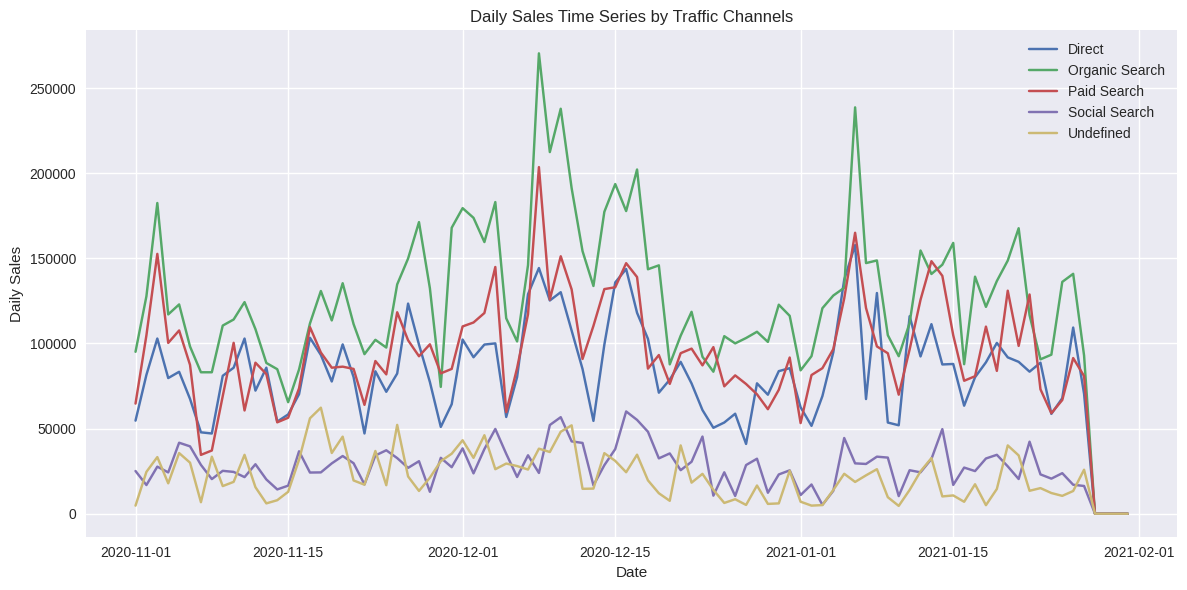

In [ ]:
# Relationship between total sales by traffic channels
pivot_channel = df.groupby(["date", "traffic_channel"])["price"].sum().unstack().dropna()

# Visualization
plt.figure(figsize=(12,6))

for column in pivot_channel.columns:
  plt.plot(pivot_channel.index, pivot_channel[column], label=column)

plt.title("Daily Sales Time Series by Traffic Channels")
plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.legend()
plt.tight_layout()
plt.show()

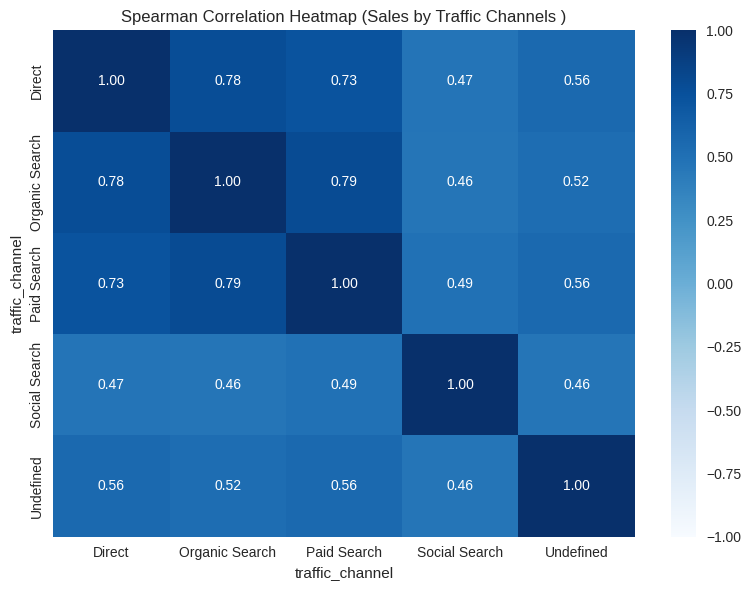

In [ ]:
# Calculate Spearman correlation coefficient
spearman_corr = pivot_channel.corr(method="spearman")

# Visualization
plt.figure(figsize=(8,6))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="Blues", vmin=-1, vmax=1)
plt.title("Spearman Correlation Heatmap (Sales by Traffic Channels )")
plt.tight_layout()
plt.show()

In [ ]:
# p-values
p_values = pivot_channel.corr(method=lambda x, y: spearmanr(x, y)[1])
p_values

traffic_channel,Direct,Organic Search,Paid Search,Social Search,Undefined
traffic_channel,,,,,
Direct,1.000000e+00,5.405254e-20,1.654022e-16,2.365556e-06,8.156167e-09
Organic Search,5.405254e-20,1.000000e+00,4.161837e-21,3.645214e-06,7.935218e-08
Paid Search,1.654022e-16,4.161837e-21,1.000000e+00,6.058888e-07,8.421903e-09
Social Search,2.365556e-06,3.645214e-06,6.058888e-07,1.000000e+00,3.453229e-06
Undefined,8.156167e-09,7.935218e-08,8.421903e-09,3.453229e-06,1.000000e+00


(EN)

Sales across different traffic channels show **moderate to strong positive correlations** (Spearman correlation coefficients **ρ ≈ 0.46–0.79**).

All identified correlations are **statistically significant** (**p < 0.05**), which means that sales trends are consistent across traffic channels.

(PL)

Sprzedaż w różnych kanałach ruchu wykazuje **umiarkowaną i silną dodatnią korelację** (współczynniki korelacji Spearmana **ρ ≈ 0,46–0,79**).

Wszystkie zidentyfikowane korelacje są **statystycznie istotne** (**p < 0,05**), co wskazuje na spójną dynamikę sprzedaży pomiędzy kanałami ruchu.

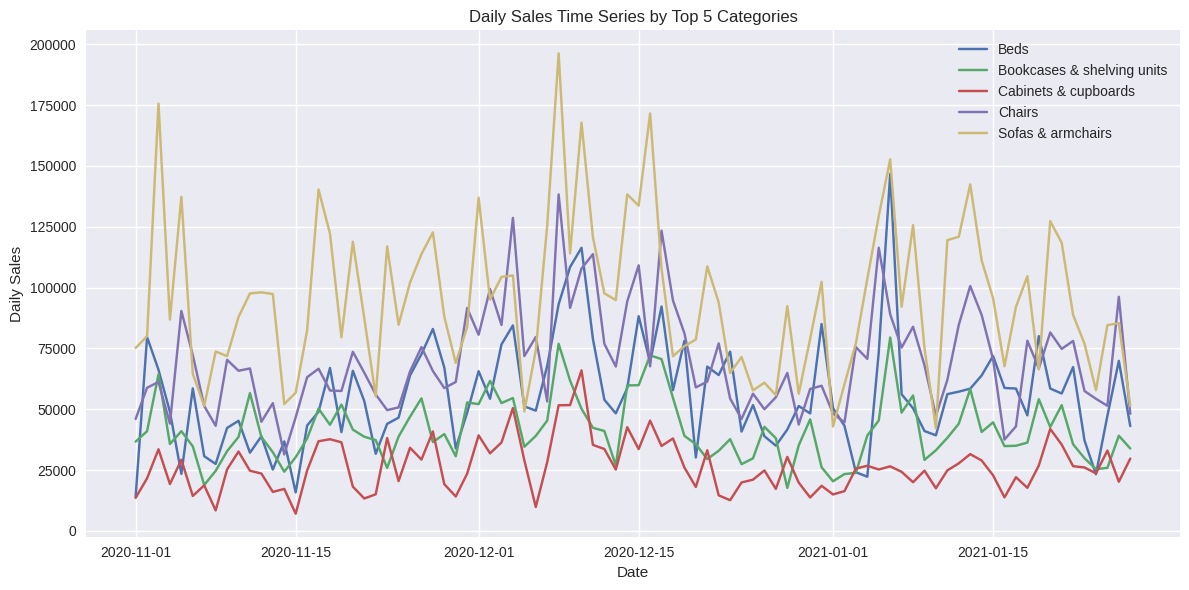

In [ ]:
# Relationship between total sales by Top 5 categories
# Top 5 categories by total sales
top_5_categories = df.groupby("category")["price"].sum().sort_values(ascending=False).head(5).index

pivot_category = df[df["category"].isin(top_5_categories)].groupby(["date", "category"])["price"].sum().unstack().dropna()

# Visualization
plt.figure(figsize=(12,6))

for column in pivot_category.columns:
  plt.plot(pivot_category.index, pivot_category[column], label=column)

plt.title("Daily Sales Time Series by Top 5 Categories")
plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.legend()
plt.tight_layout()
plt.show()

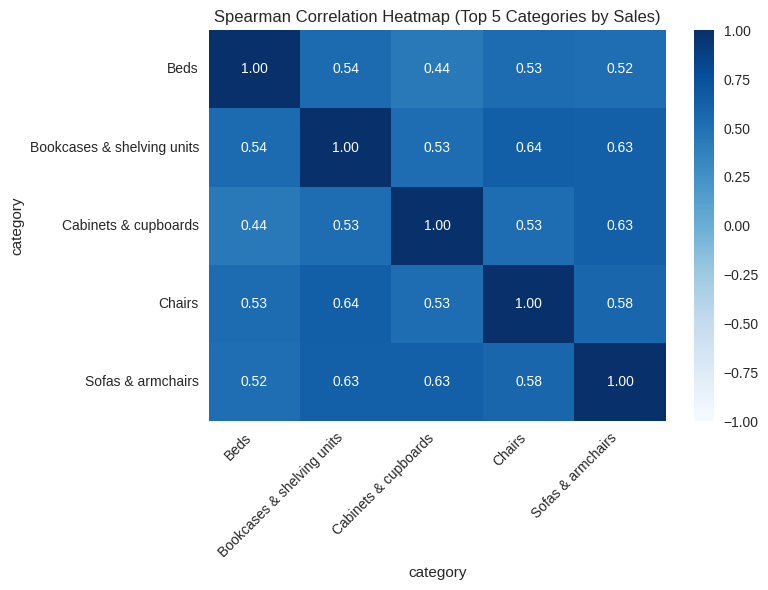

In [ ]:
# Calculate Spearman correlation
spearman_corr = pivot_category.corr(method="spearman")

# Visualization
plt.figure(figsize=(8,6))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="Blues", vmin=-1, vmax=1)
plt.title("Spearman Correlation Heatmap (Top 5 Categories by Sales)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# p-values
p_values = pivot_category.corr(method=lambda x, y: spearmanr(x, y)[1])
p_values

category,Beds,Bookcases & shelving units,Cabinets & cupboards,Chairs,Sofas & armchairs
category,,,,,
Beds,1.000000e+00,4.690832e-08,1.758783e-05,7.913416e-08,1.864368e-07
Bookcases & shelving units,4.690832e-08,1.000000e+00,1.190613e-07,2.585438e-11,7.188991e-11
Cabinets & cupboards,1.758783e-05,1.190613e-07,1.000000e+00,1.344915e-07,4.322908e-11
Chairs,7.913416e-08,2.585438e-11,1.344915e-07,1.000000e+00,2.462820e-09
Sofas & armchairs,1.864368e-07,7.188991e-11,4.322908e-11,2.462820e-09,1.000000e+00


(EN)

Sales across the top 5 product categories show **moderate to strong positive correlations** (Spearman correlation coefficients **ρ ≈ 0.44–0.64**).

All observed correlations are **statistically significant** (**p < 0.05**), which means that sales trends are consistent across the main product categories.

(PL)

Sprzedaż w podziale na Top 5 kategorii produktów wykazuje **umiarkowaną i silną dodatnią korelację** (współczynniki korelacji Spearmana **ρ ≈ 0,44–0,64**).

Wszystkie zaobserwowane korelacje są **statystycznie istotne** (**p < 0,05**), co wskazuje na spójną dynamikę sprzedaży pomiędzy głównymi kategoriami produktowymi.

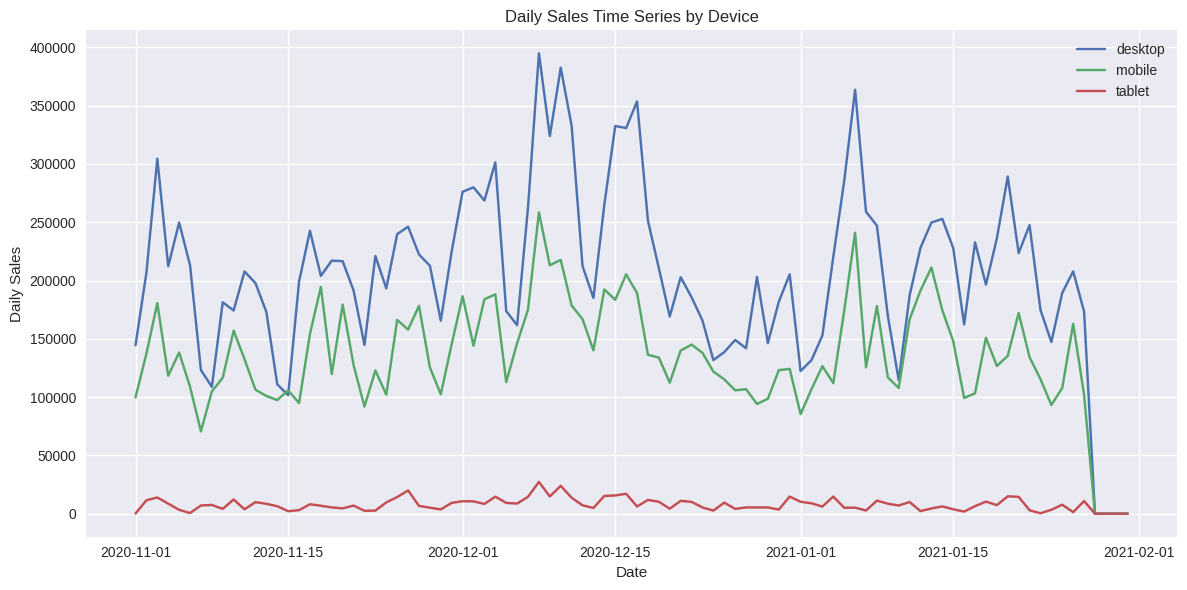

In [ ]:
# Relationship between total sales by device types
pivot_device = df.groupby(["date", "device"])["price"].sum().unstack().dropna()

# Visualization
plt.figure(figsize=(12,6))

for column in pivot_device.columns:
  plt.plot(pivot_device.index, pivot_device[column], label=column)

plt.title("Daily Sales Time Series by Device")
plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.legend()
plt.tight_layout()
plt.show()

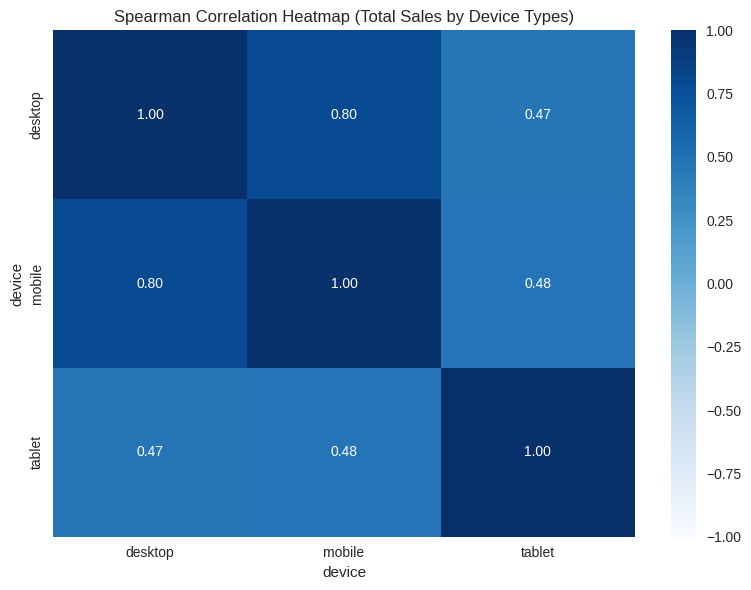

In [ ]:
# Calculate Spearman correlation
spearman_corr = pivot_device.corr(method="spearman")

# Visualization
plt.figure(figsize=(8,6))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="Blues", vmin=-1, vmax=1)
plt.title("Spearman Correlation Heatmap (Total Sales by Device Types)")
plt.tight_layout()
plt.show()

In [ ]:
# p-values
p_values = pivot_device.corr(method=lambda x, y: spearmanr(x, y)[1])
p_values

device,desktop,mobile,tablet
device,,,
desktop,1.000000e+00,1.408403e-21,0.000003
mobile,1.408403e-21,1.000000e+00,0.000002
tablet,2.794144e-06,1.609878e-06,1.000000


(EN)

Sales by device type show a **positive correlation**.

There is a **very strong positive correlation** between desktop and mobile sales (**ρ ≈ 0.80**). Correlations with tablets are **moderate** (**ρ ≈ 0.47–0.48**).

All relationships are **statistically significant** (**p < 0.05**), which means that sales trends are consistent across different device types.

(PL)

Sprzedaż według typów urządzeń wykazuje **dodatnią korelację**.

Między sprzedażą na desktop i mobile obserwowana jest **bardzo silna dodatnia korelacja** (**ρ ≈ 0,80**), natomiast korelacje z tabletami mają **umiarkowany charakter** (**ρ ≈ 0,47–0,48**).

Wszystkie zależności są **statystycznie istotne** (**p < 0,05**), co wskazuje na spójną dynamikę sprzedaży pomiędzy różnymi typami urządzeń.


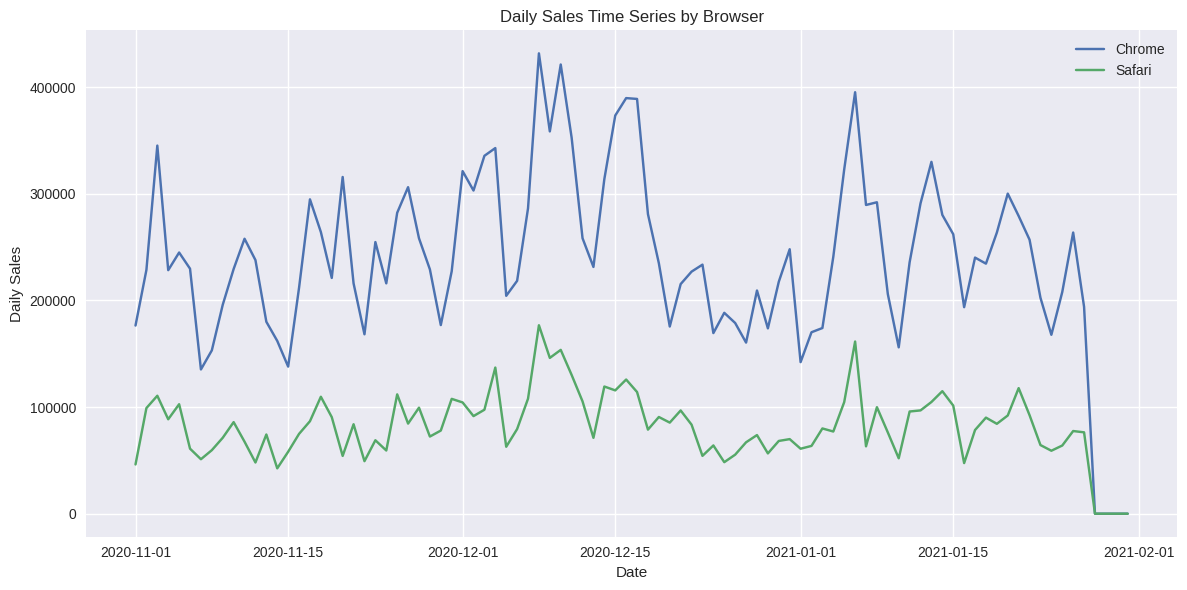

In [ ]:
# Relationship between total sales by browsers (Chrome, Safari)
# Browsers by total sales
top_3_browser = df[df["browser"].isin(["Chrome", "Safari"])].groupby("browser")["price"].sum().sort_values(ascending=False).index

pivot_browser= df[df["browser"].isin(top_3_browser)].groupby(["date", "browser"])["price"].sum().unstack().dropna()

# Visualization
plt.figure(figsize=(12,6))

for column in pivot_browser.columns:
  plt.plot(pivot_browser.index, pivot_browser[column], label=column)

plt.title("Daily Sales Time Series by Browser")
plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Calculate Spearman correlation
spearman_corr = pivot_browser.corr(method="spearman").round(2)
spearman_corr

browser,Chrome,Safari
browser,,
Chrome,1.00,0.79
Safari,0.79,1.00


In [ ]:
# p-values
p_values = pivot_browser.corr(method=lambda x, y: spearmanr(x, y)[1])
p_values

browser,Chrome,Safari
browser,,
Chrome,1.000000e+00,4.404828e-21
Safari,4.404828e-21,1.000000e+00


(EN)

Sales by browser (Chrome and Safari) show a **strong positive correlation** (Spearman correlation coefficient **ρ ≈ 0.79**).

This relationship is **statistically significant** (**p < 0.05**), which suggests similar sales trends between these two browsers.

(PL)

Sprzedaż według przeglądarek (Chrome i Safari) wykazuje **silną dodatnią korelację** (współczynnik korelacji Spearmana **ρ ≈ 0,79**).

Zależność ta jest **statystycznie istotna** (**p < 0,05**), co sugeruje spójną dynamikę sprzedaży pomiędzy tymi dwoma przeglądarkami.

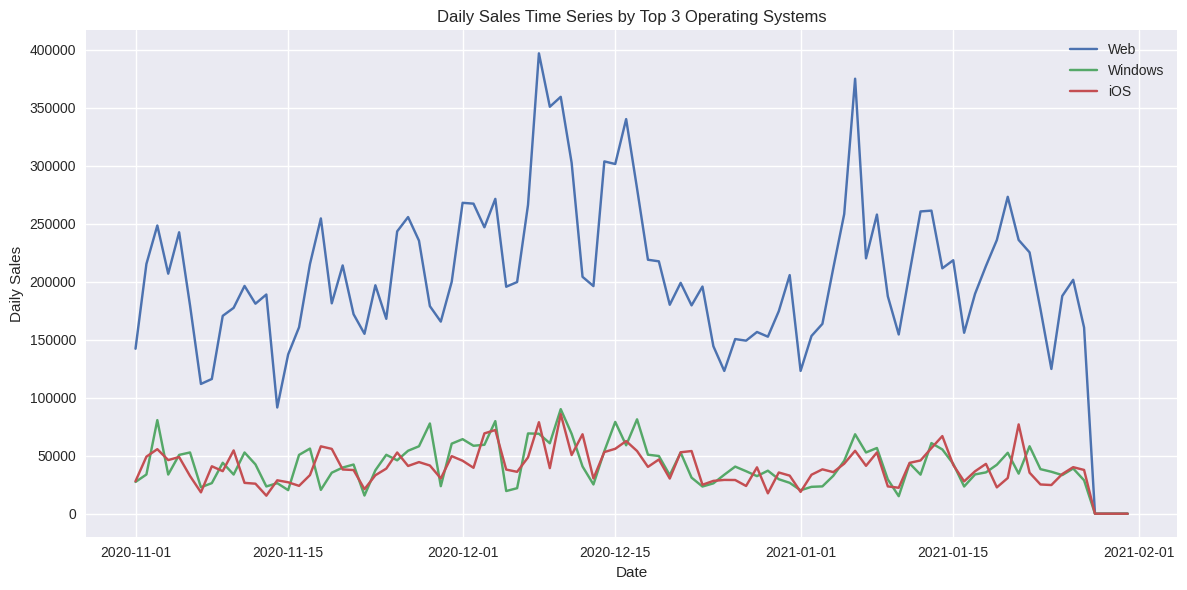

In [ ]:
# Relationship between total sales by Top 3 operating systems
# Top 3 operating systems by total sales
top_3_oper_system = df.groupby("operating_system")["price"].sum().sort_values(ascending=False).head(3).index

# Aggregate daily sales and pivot
pivot_system= df[df["operating_system"].isin(top_3_oper_system)].groupby(["date", "operating_system"])["price"].sum().unstack().dropna()

# Visualization
plt.figure(figsize=(12,6))

for column in pivot_system.columns:
  plt.plot(pivot_system.index, pivot_system[column], label=column)

plt.title("Daily Sales Time Series by Top 3 Operating Systems")
plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.legend()
plt.tight_layout()
plt.show()

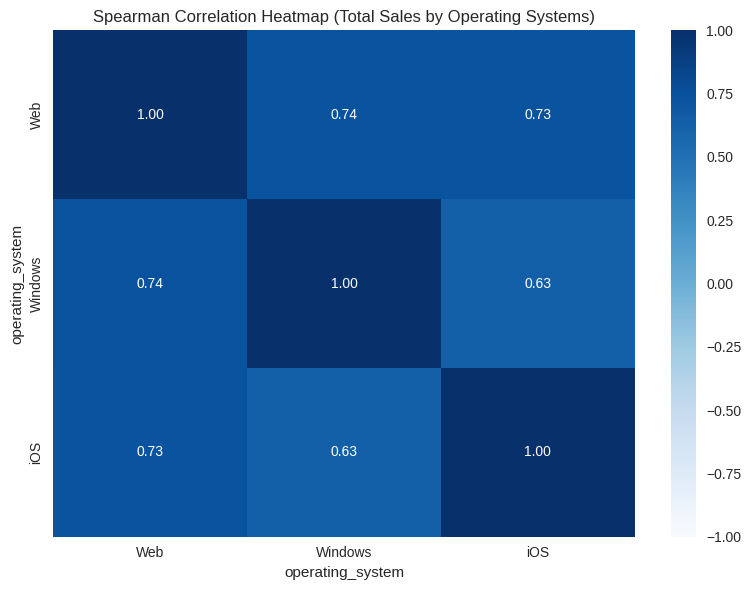

In [ ]:
# Calculate Spearman correlation
spearman_corr = pivot_system.corr(method="spearman")

# Visualization
plt.figure(figsize=(8,6))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="Blues", vmin=-1, vmax=1)
plt.title("Spearman Correlation Heatmap (Total Sales by Operating Systems)")
plt.tight_layout()
plt.show()

In [ ]:
# p-values
p_values = pivot_system.corr(method=lambda x, y: spearmanr(x, y)[1])
p_values

operating_system,Web,Windows,iOS
operating_system,,,
Web,1.000000e+00,3.506097e-17,2.355924e-16
Windows,3.506097e-17,1.000000e+00,2.069651e-11
iOS,2.355924e-16,2.069651e-11,1.000000e+00


(EN)

Sales across the three operating systems (Web, Windows, iOS) show a **strong positive correlation** (Spearman correlation coefficients **ρ ≈ 0.63–0.74**).

All observed relationships are **statistically significant** (**p < 0.05**), which means that sales trends are consistent across different operating systems.

(PL)

Sprzedaż według trzech systemów operacyjnych (Web, Windows, iOS) wykazuje **silną dodatnią korelację** (współczynniki korelacji Spearmana **ρ ≈ 0,63–0,74**).

Wszystkie zaobserwowane zależności są **statystycznie istotne** (**p < 0,05**), co wskazuje na spójną dynamikę sprzedaży pomiędzy różnymi systemami operacyjnymi.


# **7. Statistical analysis of differences between groups**

P-value: 3.88e-26


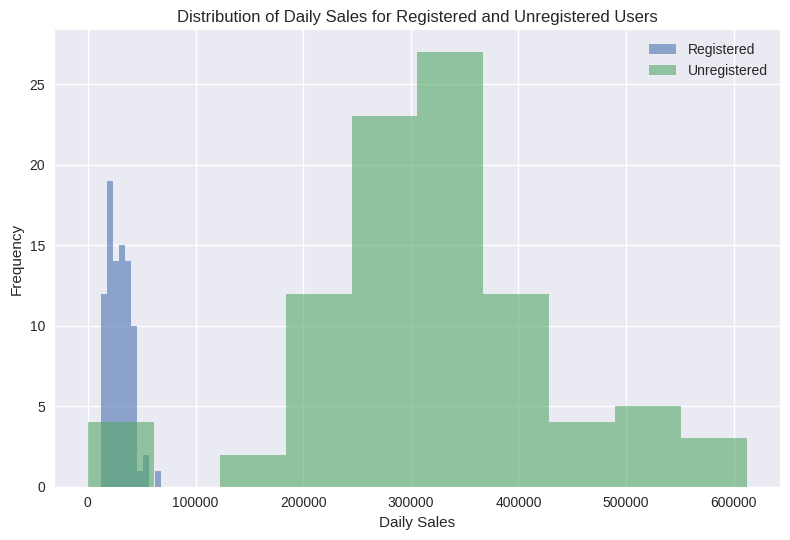

In [ ]:
# Distribution of daily sales for registered and unregistered users
# Registered/Unregistered
df["is_registered"] = df["account_id"].notna()

# Daily sales by group
daily_sales = df.groupby(["date", "is_registered"])["price"].sum().unstack()

# Samples
registered = daily_sales[True].dropna()
unregistered = daily_sales[False].dropna()

# Visualization
registered.hist(alpha=0.6, label="Registered")
unregistered.hist(alpha=0.6, label="Unregistered")
plt.title("Distribution of Daily Sales for Registered and Unregistered Users")
plt.xlabel("Daily Sales")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()

# Comparison of two samples
U, p_value = mannwhitneyu(registered, unregistered)

print(f"P-value: {p_value:.2e}")

(EN)

The **Mann–Whitney (U)** test showed that the differences between the two samples are **statistically significant** (**p < 0.05**). This means that the distributions of daily sales in the two groups are different.

(PL)

Test **Manna–Whitneya (U)** wykazał, że różnice pomiędzy obiema próbami są **statystycznie istotne** (**p < 0.05**), co wskazuje na odmienne rozkłady dziennych sprzedaży w obu grupach.

P-value: 1.40e-78


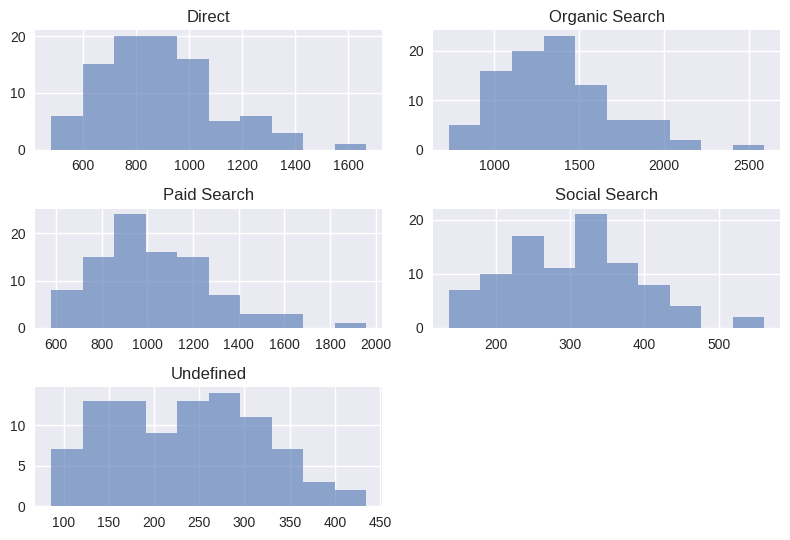

In [ ]:
# Distribution of daily sessions for different traffic channels
# Daily sessions by traffic channel
daily_sessions = df.groupby(["date", "traffic_channel"])["ga_session_id"].count().unstack()

# Visualization
daily_sessions.hist(alpha=0.6)
plt.tight_layout()

# Perform the Kruskal-Wallis test
H, p_value = kruskal(
    daily_sessions["Direct"].dropna(),
    daily_sessions["Organic Search"].dropna(),
    daily_sessions["Paid Search"].dropna(),
    daily_sessions["Social Search"].dropna(),
    daily_sessions["Undefined"].dropna()
)

print(f"P-value: {p_value:.2e}")

(EN)

The **Kruskal–Wallis (H)** test showed that the differences between the analyzed groups are **statistically significant** (**p < 0.05**). This means that the number of sessions differs depending on the traffic channel.

(PL)

Test **Kruskala–Wallisa (H)** wykazał, że różnice pomiędzy analizowanymi grupami są **statystycznie istotne** (**p < 0,05**), co oznacza, że liczba sesji różni się w zależności od kanału ruchu.

In [ ]:
# Comparison of Organic Traffic Share Between Europe and the Americas
# Europe & Americas
df_eu_us = df[df["continent"].isin(["Europe", "Americas"])]

# Total sessions by continent
total_sessions = df_eu_us.groupby("continent")["ga_session_id"].count()

# Organic Search Sessions
organic_sessions = df_eu_us[df_eu_us["traffic_channel"] == "Organic Search"].groupby("continent")["ga_session_id"].count()

# Total sessions
total_eu = total_sessions["Europe"]
total_us = total_sessions["Americas"]

# Organic sessions
organic_eu = organic_sessions["Europe"]
organic_us = organic_sessions["Americas"]

# Perform z-test for two proportions
z_stat, p_value = sm.stats.proportions_ztest([organic_eu, organic_us], [total_eu, total_us])

print(f"P-value: {p_value}")

P-value: 0.7721879690501752


(EN)

**The two-proportion (Z) test** showed **no statistically significant** differences between the analyzed regions (**p > 0.05**). This means that the share of organic traffic is similar in Europe and the Americas.

(PL)

**Test dla dwóch proporcji (Z)** wykazał **brak** statystycznie istotnych różnic pomiędzy analizowanymi regionami (**p > 0,05**), co oznacza, że udział ruchu organicznego jest porównywalny w Europie i Amerykach.

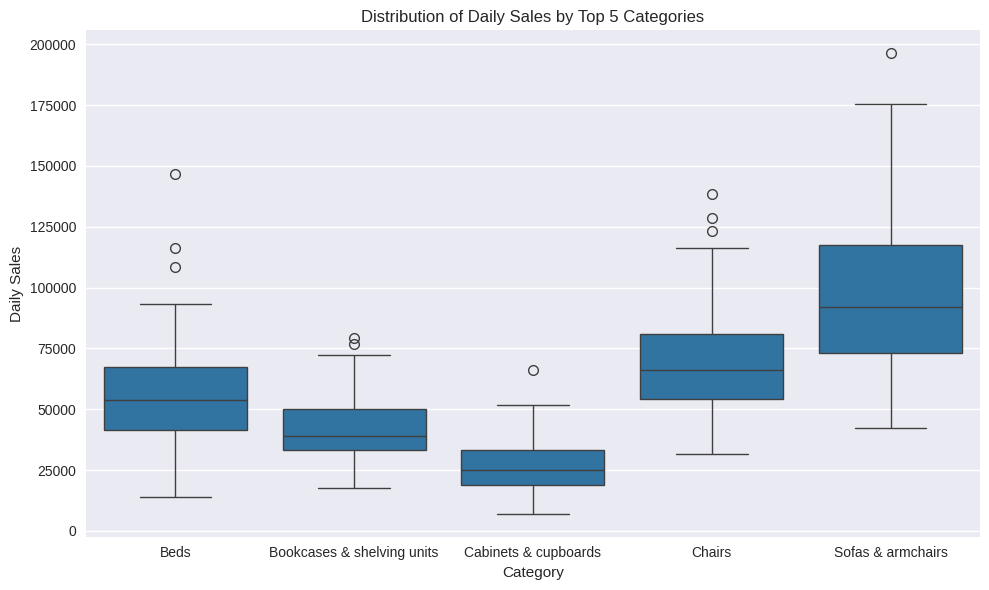

P-value: 9.89e-76


In [ ]:
# Distribution of daily sales by top 5 categories
# TOP 5 categories by total sales
top_5_categories = df.groupby("category")["price"].sum().sort_values(ascending=False).head(5).index

# Daily sales per category
sales_by_date_category = df[df["category"].isin(top_5_categories)].groupby(["date", "category"])["price"].sum().reset_index()

# Samples
groups = [sales_by_date_category[sales_by_date_category["category"] == category]["price"] for category in top_5_categories]

# Visualization
plt.figure(figsize=(10, 6))
sns.boxplot(data=sales_by_date_category, x="category", y="price", color="tab:blue")
plt.title("Distribution of Daily Sales by Top 5 Categories")
plt.xlabel("Category")
plt.ylabel("Daily Sales")
plt.tight_layout()
plt.show()

# Performing ANOVA test
F, p_value = f_oneway(*groups)

print(f"P-value: {p_value:.2e}")

(EN)

The **ANOVA (F)** test showed **statistically significant** differences in average daily sales between the top 5 product categories (**p < 0.05**).

This means that the average sales level differs depending on the product category.

(PL)

Test **ANOVA** (**F**) wykazał, że pomiędzy Top 5 kategoriami produktów występują **statystycznie istotne** różnice w średnich dziennych sprzedażach (**p < 0,05**).

Oznacza to, że średni poziom sprzedaży istotnie różni się w zależności od kategorii produktu.

# **8. Tableau Dashboards**

In [ ]:
# Saving data for visualization in Tableau
from google.colab import drive

drive.mount("/content/drive")

df.to_csv("/content/drive/MyDrive/dashboard_data.csv", index=False)

Mounted at /content/drive


[Tableau Dashboards](https://public.tableau.com/views/BusinessPerformanceOverview_17706814943080/BusinessPerformanceOverviewSalesMarket?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)